In [7]:

import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Flatten ,Dropout ,Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2


In [ ]:
IMG_SIZE = (224, 224)
BBATCH_SIZE = 32
EPOCHS = 10
N_TRAIN = 4000
N_TEST = 800
NUM_CLASSES = 20
NUM_CLASSES_WITH_BG = NUM_CLASSES + 1
MAX_OBJECTS = 10

VOC_LABELS = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle','bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

In [9]:
ds_train,ds_val = tfds.load('voc/2007', split=['train+validation', 'test'], as_supervised=False)

In [10]:
# Discards any image that has zero annotated objects
def has_object(example):
    n=tf.shape(example['objects']['bbox'])[0]
    return n > 0

In [ ]:

def preprocess_data(sample):
    image = tf.cast(sample['image'], tf.float32)
    bboxes = sample['objects']['bbox']
    labels = sample['objects']['label']

    image = tf.image.resize(image, IMG_SIZE) / 255.0

    # VOC bbox comes as [ymin, xmin, ymax, xmax]; convert to [xmin, ymin, xmax, ymax]
    x_min = bboxes[:, 1]
    y_min = bboxes[:, 0]
    x_max = bboxes[:, 3]
    y_max = bboxes[:, 2]
    bboxes = tf.stack([x_min, y_min, x_max, y_max], axis=-1)

    # Keep all objects up to MAX_OBJECTS and pad for fixed-shape batching
    bboxes = bboxes[:MAX_OBJECTS]
    labels = labels[:MAX_OBJECTS]

    labels = tf.one_hot(labels, depth=NUM_CLASSES, dtype=tf.float32)

    num_objects = tf.shape(bboxes)[0]
    pad_count = MAX_OBJECTS - num_objects

    bboxes = tf.pad(bboxes, paddings=[[0, pad_count], [0, 0]], constant_values=0.0)
    labels = tf.pad(labels, paddings=[[0, pad_count], [0, 0]], constant_values=0.0) 

    return image, {'label_target': labels, 'bbox_target': bboxes}


In [ ]:
# Builds the dataset pipeline: filter out images without objects and preprocess
ds_train = ds_train.filter(has_object)

ds_val = ds_val.filter(has_object)

ds_train = ds_train.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)\
    .shuffle(1000).batch(BBATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_val = ds_val.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BBATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [13]:
def masked_bbox_mse(y_true, y_pred):
    mask = tf.cast(tf.reduce_sum(y_true, axis=-1) > 0.0, tf.float32)
    sq_err = tf.reduce_sum(tf.square(y_true - y_pred), axis=-1)
    sq_err = sq_err * mask
    denom = tf.maximum(tf.reduce_sum(mask), 1.0)
    return tf.reduce_sum(sq_err) / denom

def iou_metric(y_true, y_pred):
    # y_true/y_pred: [batch, MAX_OBJECTS, 4]
    x_1_true = y_true[..., 0]
    y_1_true = y_true[..., 1]
    x_2_true = y_true[..., 2]
    y_2_true = y_true[..., 3]

    x_1_pred = y_pred[..., 0]
    y_1_pred = y_pred[..., 1]
    x_2_pred = y_pred[..., 2]
    y_2_pred = y_pred[..., 3]

    x_left = tf.maximum(x_1_true, x_1_pred)
    y_top = tf.maximum(y_1_true, y_1_pred)
    x_right = tf.minimum(x_2_true, x_2_pred)
    y_bottom = tf.minimum(y_2_true, y_2_pred)

    intersection_area = tf.maximum(0.0, x_right - x_left) * tf.maximum(0.0, y_bottom - y_top)
    true_area = tf.maximum(0.0, x_2_true - x_1_true) * tf.maximum(0.0, y_2_true - y_1_true)
    pred_area = tf.maximum(0.0, x_2_pred - x_1_pred) * tf.maximum(0.0, y_2_pred - y_1_pred)
    union_area = true_area + pred_area - intersection_area
    iou = tf.where(union_area > 0, intersection_area / union_area, tf.zeros_like(intersection_area))

    mask = tf.cast(true_area > 0.0, tf.float32)
    denom = tf.maximum(tf.reduce_sum(mask), 1.0)
    return tf.reduce_sum(iou * mask) / denom


In [14]:
# Loads a MobileNetV2 pretrained on ImageNet as the feature extractor. 
backbone = tf.keras.applications.MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
# Freeze the backbone to prevent its weights from being updated during training
backbone.trainable = False

In [15]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = backbone(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

label_target = Dense(MAX_OBJECTS * NUM_CLASSES, activation='sigmoid')(x)
label_target = tf.keras.layers.Reshape((MAX_OBJECTS, NUM_CLASSES), name='label_target')(label_target)

bbox_target = Dense(MAX_OBJECTS * 4, activation='sigmoid')(x)
bbox_target = tf.keras.layers.Reshape((MAX_OBJECTS, 4), name='bbox_target')(bbox_target)

model = tf.keras.Model(inputs=inputs, outputs=[label_target, bbox_target])
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={'label_target': 'binary_crossentropy', 'bbox_target': masked_bbox_mse},
    metrics={'label_target': 'binary_accuracy', 'bbox_target': iou_metric}
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 200)       │     51,400 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 40)        │     10,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_target        │ (None, 10, 20)    │          0 │ dense_1[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_target         │ (None, 10, 4)     │          0 │ dense_2[0][0]     │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,647,600 (10.10 MB)

 Trainable params: 389,616 (1.49 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS+20)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - bbox_target_iou_metric: 0.2684 - bbox_target_loss: 0.0833 - label_target_binary_accuracy: 0.9895 - label_target_loss: 0.0294 - loss: 0.1126 - val_bbox_target_iou_metric: 0.1830 - val_bbox_target_loss: 0.2313 - val_label_target_binary_accuracy: 0.9884 - val_label_target_loss: 0.0386 - val_loss: 0.2700
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - bbox_target_iou_metric: 0.2725 - bbox_target_loss: 0.0825 - label_target_binary_accuracy: 0.9895 - label_target_loss: 0.0288 - loss: 0.1113 - val_bbox_target_iou_metric: 0.1802 - val_bbox_target_loss: 0.2337 - val_label_target_binary_accuracy: 0.9883 - val_label_target_loss: 0.0386 - val_loss: 0.2724
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - bbox_target_iou_metric: 0.2763 - bbox_target_loss: 0.0809 - label_target_binary_accuracy: 0.9897 - label_target_loss: 0.0283 - loss: 0.1092 - val_bbox_target_iou_metric: 0.1853 - val_bbox_target_loss: 0.2325 - val_label_targe

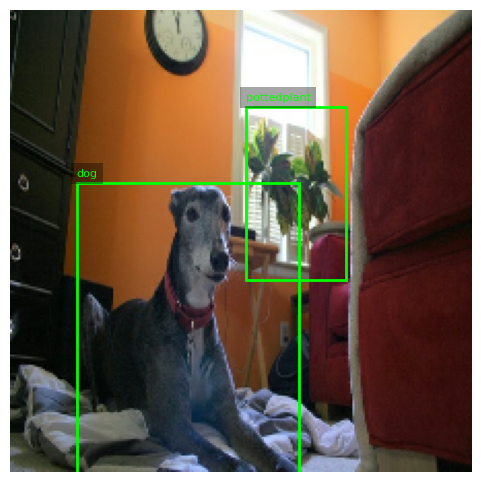

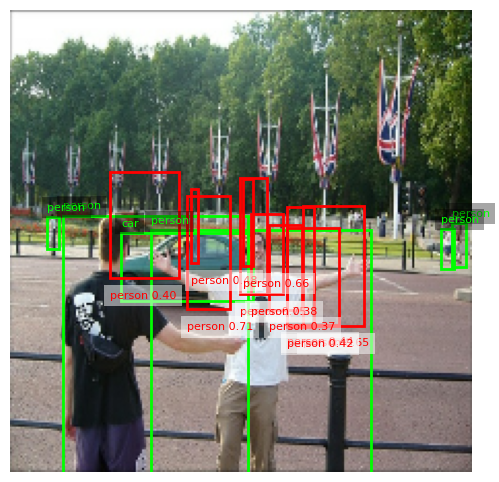

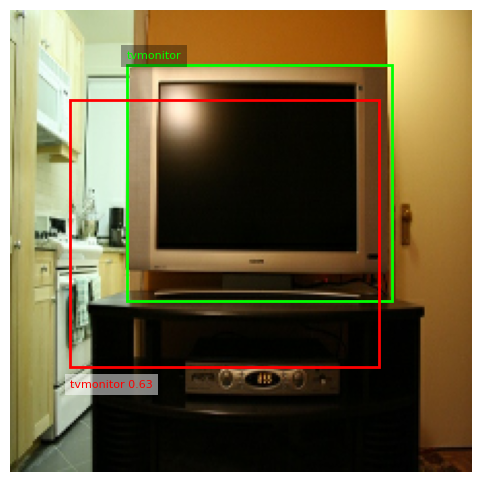

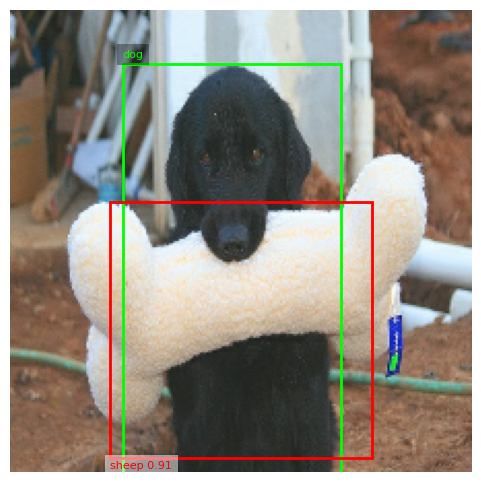

In [28]:
# Visualize all predicted and ground-truth objects for a few validation images
for batch_images, batch_targets in ds_val.take(1):
    pred_labels, pred_boxes = model.predict(batch_images[:4], verbose=0)

    for i in range(4):
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        ax.imshow(batch_images[i])

        gt_boxes = batch_targets['bbox_target'][i].numpy()
        gt_labels = batch_targets['label_target'][i].numpy()
        pred_b = pred_boxes[i]
        pred_l = pred_labels[i]

        # Ground truth boxes in green
        for j in range(MAX_OBJECTS):
            if np.sum(gt_boxes[j]) <= 0:
                continue
            x1, y1, x2, y2 = gt_boxes[j]
            rect = plt.Rectangle((x1 * IMG_SIZE[1], y1 * IMG_SIZE[0]),
                                 (x2 - x1) * IMG_SIZE[1],
                                 (y2 - y1) * IMG_SIZE[0],
                                 fill=False, edgecolor='lime', linewidth=2)
            ax.add_patch(rect)
            gt_cls_id = int(np.argmax(gt_labels[j]))
            ax.text(x1 * IMG_SIZE[1], max(y1 * IMG_SIZE[0] - 3, 0),
                    VOC_LABELS[gt_cls_id], color='lime', fontsize=8,
                    bbox=dict(facecolor='black', alpha=0.35, edgecolor='none'))

        # Predicted boxes in red
        for j in range(MAX_OBJECTS):
            cls_id = int(np.argmax(pred_l[j]))
            cls_conf = float(np.max(pred_l[j]))
            if cls_conf < 0.35:
                continue
            x1, y1, x2, y2 = pred_b[j]
            if x2 <= x1 or y2 <= y1:
                continue
            rect = plt.Rectangle((x1 * IMG_SIZE[1], y1 * IMG_SIZE[0]),
                                 (x2 - x1) * IMG_SIZE[1],
                                 (y2 - y1) * IMG_SIZE[0],
                                 fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(x1 * IMG_SIZE[1], min(y2 * IMG_SIZE[0] + 10, IMG_SIZE[0] - 2),
                    f"{VOC_LABELS[cls_id]} {cls_conf:.2f}", color='red', fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

        ax.set_axis_off()
        plt.show()
